In [1]:
import os
from pathlib import Path
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [2]:

# Enforce reproducibility across stochastic processes
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)


In [3]:
# Centralized configuration class
class Config:
    # Data parameters
    VOCAB_SIZE = 5000
    MAX_LEN = 100
    BATCH_SIZE = 64
    
    # Model parameters
    EMBEDDING_DIM = 64
    HIDDEN_DIM = 128
    OUTPUT_DIM = 2
    
    # Training parameters
    EPOCHS = 6
    LR = 0.001
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # File Paths
    BASE_PATH = Path.cwd() / "imdb"
    TRAIN_PATH = BASE_PATH / "Train.csv"
    VALID_PATH = BASE_PATH / "Valid.csv"
    test_path = BASE_PATH / "Test.csv"

print(f"Systematic pipeline configured. Executing calculations on: {Config.DEVICE}")

Systematic pipeline configured. Executing calculations on: cpu


In [4]:
# 1. Load data partitions from disk
print("Loading CSV partitions...")
# Updating the cell 2 with these lines to cap the dataset size:
df_train = pd.read_csv(Config.TRAIN_PATH).sample(n=2000, random_state=42)
df_valid = pd.read_csv(Config.VALID_PATH).sample(n=500, random_state=42)
df_test = pd.read_csv(Config.test_path).sample(n=500, random_state=42)
print("Successfully done loading all the datasets")

Loading CSV partitions...
Successfully done loading all the datasets


In [5]:
# 2. Text preprocessing utility
def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)  # Strip out HTML line breaks common in IMDB data
    text = re.sub(r'[^a-z\s]', '', text)     # Remove punctuation and numbers
    return text.split()

print("Tokenizing textual sequences...")
train_tokens = [clean_and_tokenize(t) for t in df_train['text']]
valid_tokens = [clean_and_tokenize(t) for t in df_valid['text']]
test_tokens = [clean_and_tokenize(t) for t in df_test['text']]

# 3. Build Vocabulary (Strictly from the training set to prevent leakage)
print("Building vocabulary indices...")
all_train_words = [word for text in train_tokens for word in text]
word_counts = Counter(all_train_words)

# Keep the most frequent words up to VOCAB_SIZE minus 1 (reserving 0 for padding)
common_words = [word for word, _ in word_counts.most_common(Config.VOCAB_SIZE - 1)]
word_to_idx = {word: idx + 1 for idx, word in enumerate(common_words)}
word_to_idx["<PAD>"] = 0  # Explicit padding index


Tokenizing textual sequences...
Building vocabulary indices...


In [6]:

# 4. Numericalization and Padding Pipeline
def pipeline_transform(tokenized_data, mapping, max_len):
    transformed_matrix = []
    for tokens in tokenized_data:
        # Convert tokens to integers if they exist in vocabulary, else ignore (OOV handling)
        numericalized = [mapping[w] for w in tokens if w in mapping]
        
        # Apply padding or truncation to normalize vector shapes
        if len(numericalized) < max_len:
            numericalized += [mapping["<PAD>"]] * (max_len - len(numericalized))
        else:
            numericalized = numericalized[:max_len]
        transformed_matrix.append(numericalized)
    return np.array(transformed_matrix)

print("Vectorizing sets into matching sequence formats...")
X_train = pipeline_transform(train_tokens, word_to_idx, Config.MAX_LEN)
X_valid = pipeline_transform(valid_tokens, word_to_idx, Config.MAX_LEN)
X_test = pipeline_transform(test_tokens, word_to_idx, Config.MAX_LEN)

# Extract integer label arrays
y_train = df_train['label'].values
y_valid = df_valid['label'].values
y_test = df_test['label'].values

print(f"Data mapping finalized. Vocab Size: {len(word_to_idx)} | Train Matrix Shape: {X_train.shape}")

Vectorizing sets into matching sequence formats...
Data mapping finalized. Vocab Size: 5000 | Train Matrix Shape: (2000, 100)


In [7]:
# Create Tensor Dataset abstractions
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.long))
valid_dataset = TensorDataset(torch.tensor(X_valid, dtype=torch.long), torch.tensor(y_valid, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long), torch.tensor(y_test, dtype=torch.long))

# Instantiate performance streaming engines
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

print(f"Data batch engines online. Generated {len(train_loader)} batches for training operations.")

Data batch engines online. Generated 31 batches for training operations.


In [8]:
# Building the model

In [9]:
class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(SentimentGRU, self).__init__()
        
        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. Gated Recurrent Unit (GRU) Layer
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        # 3. Dense Output Layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        
        # GRU forward pass returns sequence outputs and a single hidden state vector
        # out shape: (batch_size, sequence_length, hidden_dim)
        out, hidden = self.gru(embedded)
        
        # Extract final temporal step
        last_time_step = out[:, -1, :]
        
        logits = self.fc(last_time_step)
        return logits

# Initialize GRU instance and mount onto target execution hardware
gru_model = SentimentGRU(
    vocab_size=Config.VOCAB_SIZE,
    embedding_dim=Config.EMBEDDING_DIM,
    hidden_dim=Config.HIDDEN_DIM,
    output_dim=Config.OUTPUT_DIM
).to(Config.DEVICE)

gru_criterion = nn.CrossEntropyLoss()
gru_optimizer = optim.Adam(gru_model.parameters(), lr=Config.LR)

print(gru_model)


SentimentGRU(
  (embedding): Embedding(5000, 64, padding_idx=0)
  (gru): GRU(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [10]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Executes a single training epoch across all mini-batches."""
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    for batch_x, batch_y in dataloader:
        # Move tensors to the targeted hardware acceleration unit
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # 1. Reset gradients from the previous forward pass step
        optimizer.zero_grad()
        
        # 2. Forward pass: compute predictions from the input batch
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        
        # 3. Backward pass: compute loss gradients via backpropagation
        loss.backward()
        
        # 4. Weight update: step optimization parameters based on gradients
        optimizer.step()
        
        # Track training batch metrics
        running_loss += loss.item() * batch_x.size(0)
        predictions = torch.argmax(logits, dim=1)
        correct_preds += (predictions == batch_y).sum().item()
        total_preds += batch_y.size(0)
        
    epoch_loss = running_loss / total_preds
    epoch_acc = correct_preds / total_preds
    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion, device):
    """Evaluates the model performance over the validation dataset loop."""
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    # Disable gradient tracking to conserve memory and speed up processing
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            running_loss += loss.item() * batch_x.size(0)
            predictions = torch.argmax(logits, dim=1)
            correct_preds += (predictions == batch_y).sum().item()
            total_preds += batch_y.size(0)
            
    epoch_loss = running_loss / total_preds
    epoch_acc = correct_preds / total_preds
    return epoch_loss, epoch_acc

print("Core training engines registered successfully.")


Core training engines registered successfully.


Initiating full GRU optimization loop...
Epoch 01/6 | GRU Train Loss: 0.6968 - Train Acc: 50.15% | GRU Val Loss: 0.6965 - Val Acc: 52.40%
Epoch 02/6 | GRU Train Loss: 0.6731 - Train Acc: 59.58% | GRU Val Loss: 0.6951 - Val Acc: 52.60%
Epoch 03/6 | GRU Train Loss: 0.6472 - Train Acc: 63.61% | GRU Val Loss: 0.6995 - Val Acc: 54.40%
Epoch 04/6 | GRU Train Loss: 0.6067 - Train Acc: 66.73% | GRU Val Loss: 0.7024 - Val Acc: 57.40%
Epoch 05/6 | GRU Train Loss: 0.5553 - Train Acc: 71.88% | GRU Val Loss: 0.7154 - Val Acc: 58.80%
Epoch 06/6 | GRU Train Loss: 0.5379 - Train Acc: 73.44% | GRU Val Loss: 0.7500 - Val Acc: 53.20%

Final GRU Verification Accuracy over Test Partition: 53.20%


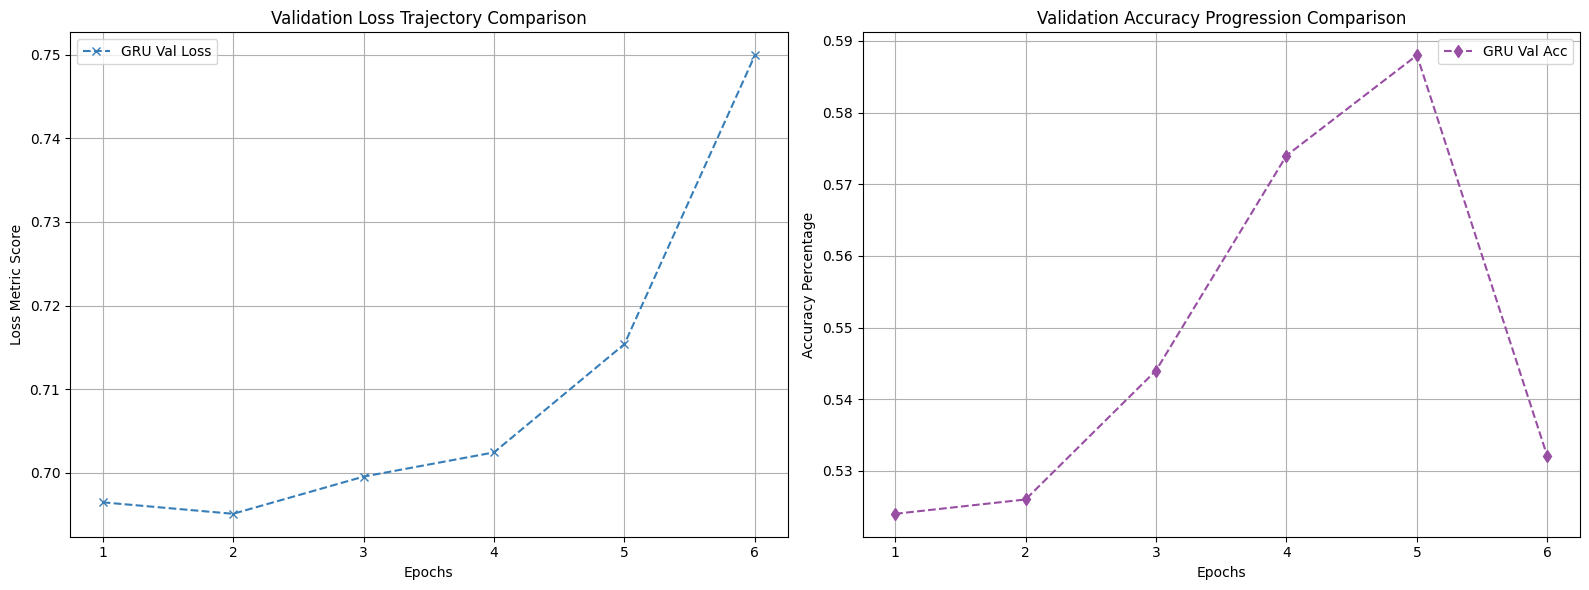


--- Architecture Performance Wrapup ---
Final GRU Test Accuracy  : 53.20%


In [11]:
gru_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("Initiating full GRU optimization loop...")
for epoch in range(Config.EPOCHS):
    # Execute structural training pass using the new GRU optimizer configurations
    train_loss, train_acc = train_one_epoch(gru_model, train_loader, gru_criterion, gru_optimizer, Config.DEVICE)
    val_loss, val_acc = validate_one_epoch(gru_model, valid_loader, gru_criterion, Config.DEVICE)
    
    gru_history['train_loss'].append(train_loss)
    gru_history['train_acc'].append(train_acc)
    gru_history['val_loss'].append(val_loss)
    gru_history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{Config.EPOCHS} | "
          f"GRU Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
          f"GRU Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

# Compute final out-of-sample benchmark
_, gru_test_acc = validate_one_epoch(gru_model, test_loader, gru_criterion, Config.DEVICE)
print(f"\nFinal GRU Verification Accuracy over Test Partition: {gru_test_acc*100:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, Config.EPOCHS + 1)

ax1.plot(epochs_range, gru_history['val_loss'], label='GRU Val Loss', color='#377eb8', marker='x', linestyle='--')
ax1.set_title('Validation Loss Trajectory Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss Metric Score')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, gru_history['val_acc'], label='GRU Val Acc', color='#984ea3', marker='d', linestyle='--')
ax2.set_title('Validation Accuracy Progression Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy Percentage')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print comparative data frame
print("\n--- Architecture Performance Wrapup ---")
print(f"Final GRU Test Accuracy  : {gru_test_acc*100:.2f}%")
